# Week 1 Internship Project – Customer Churn Prediction Using Machine Learning

## Problem Statement
## Importing Required Libraries
## Dataset Loading
## Dataset Overview
## Data Cleaning and Preprocessing
## Exploratory Data Analysis
## Feature Engineering and Encoding
## Correlation Analysis
## Model Building
### • Logistic Regression
### • Random Forest
## Model Evaluation
### • Accuracy
### • Confusion Matrix
### • Classification Report
## Model Comparison
## Business Insights
## Conclusion

## Problem Statement
 Customer churn is one of the major challenges faced by subscription-based businesses. Understanding why customers leave can help organizations improve customer retention and reduce revenue loss.

The objective of this project is to analyze customer demographics, subscribed services, contract information, and billing details to identify factors influencing churn. A machine learning model will be developed to predict whether a customer is likely to churn based on the available features.

## Importing Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Dataset Loading

In [20]:
df = pd.read_csv("Customer Churn.csv")
df.head()                                     


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

In [21]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Observation
The dataset contains customer demographic information, service usage details, contract information, and billing records. It consists of both categorical and numerical features which can be used to analyze customer behavior and predict churn.

## Data Cleaning and Preprocessing

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Observation
No significant missing values or duplicate records were found in the dataset. The SeniorCitizen feature was converted into a more interpretable categorical format to improve readability during analysis.

## Exploratory Data Analysis

### Customer Churn Distribution

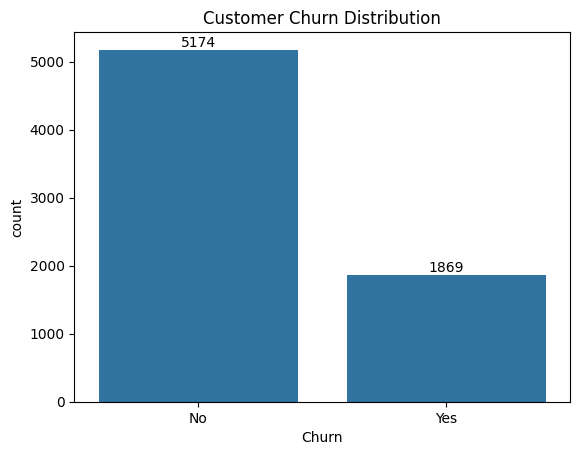

In [26]:
ax = sns.countplot(data=df, x='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.show()

### Observation

The number of customers who did not churn is significantly higher than those who churned. This indicates that most customers remain with the company, while a smaller proportion discontinue the service.

### Gender-wise Churn Analysis

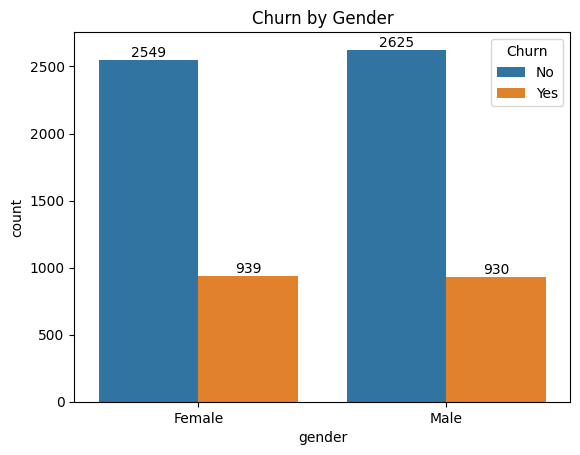

In [27]:
ax = sns.countplot(data=df, x='gender', hue='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn by Gender")
plt.show()

### Observation

The churn pattern appears similar among male and female customers. Gender alone does not seem to be a major factor influencing customer churn.

### Senior Citizen Churn Analysis

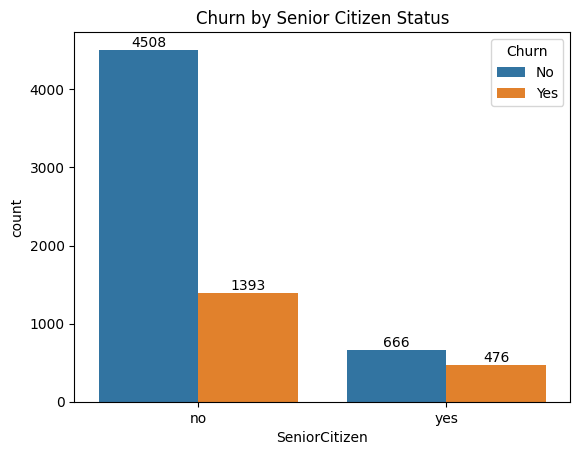

In [28]:
ax = sns.countplot(
    data=df,
    x='SeniorCitizen',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn by Senior Citizen Status")

plt.show()

### Observation

Senior citizens show a comparatively higher churn rate than non-senior customers. This suggests that customer age group may have some influence on service retention.

### Contract Type Analysis

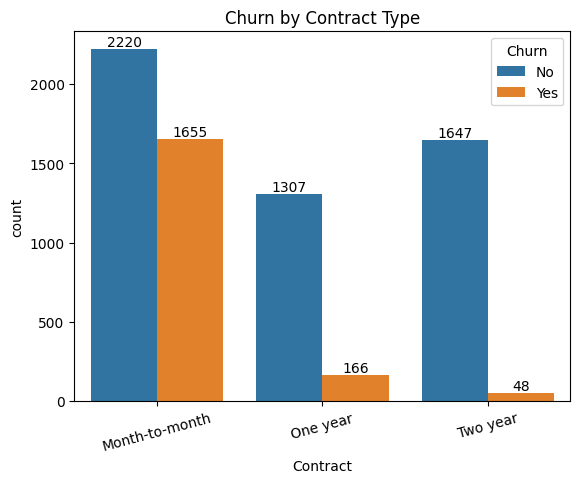

In [30]:
ax = sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

### Observation

Customers with month-to-month contracts have a higher churn rate compared to customers with one-year and two-year contracts. Longer contract durations appear to improve customer retention.

### Service-wise Churn Analysis

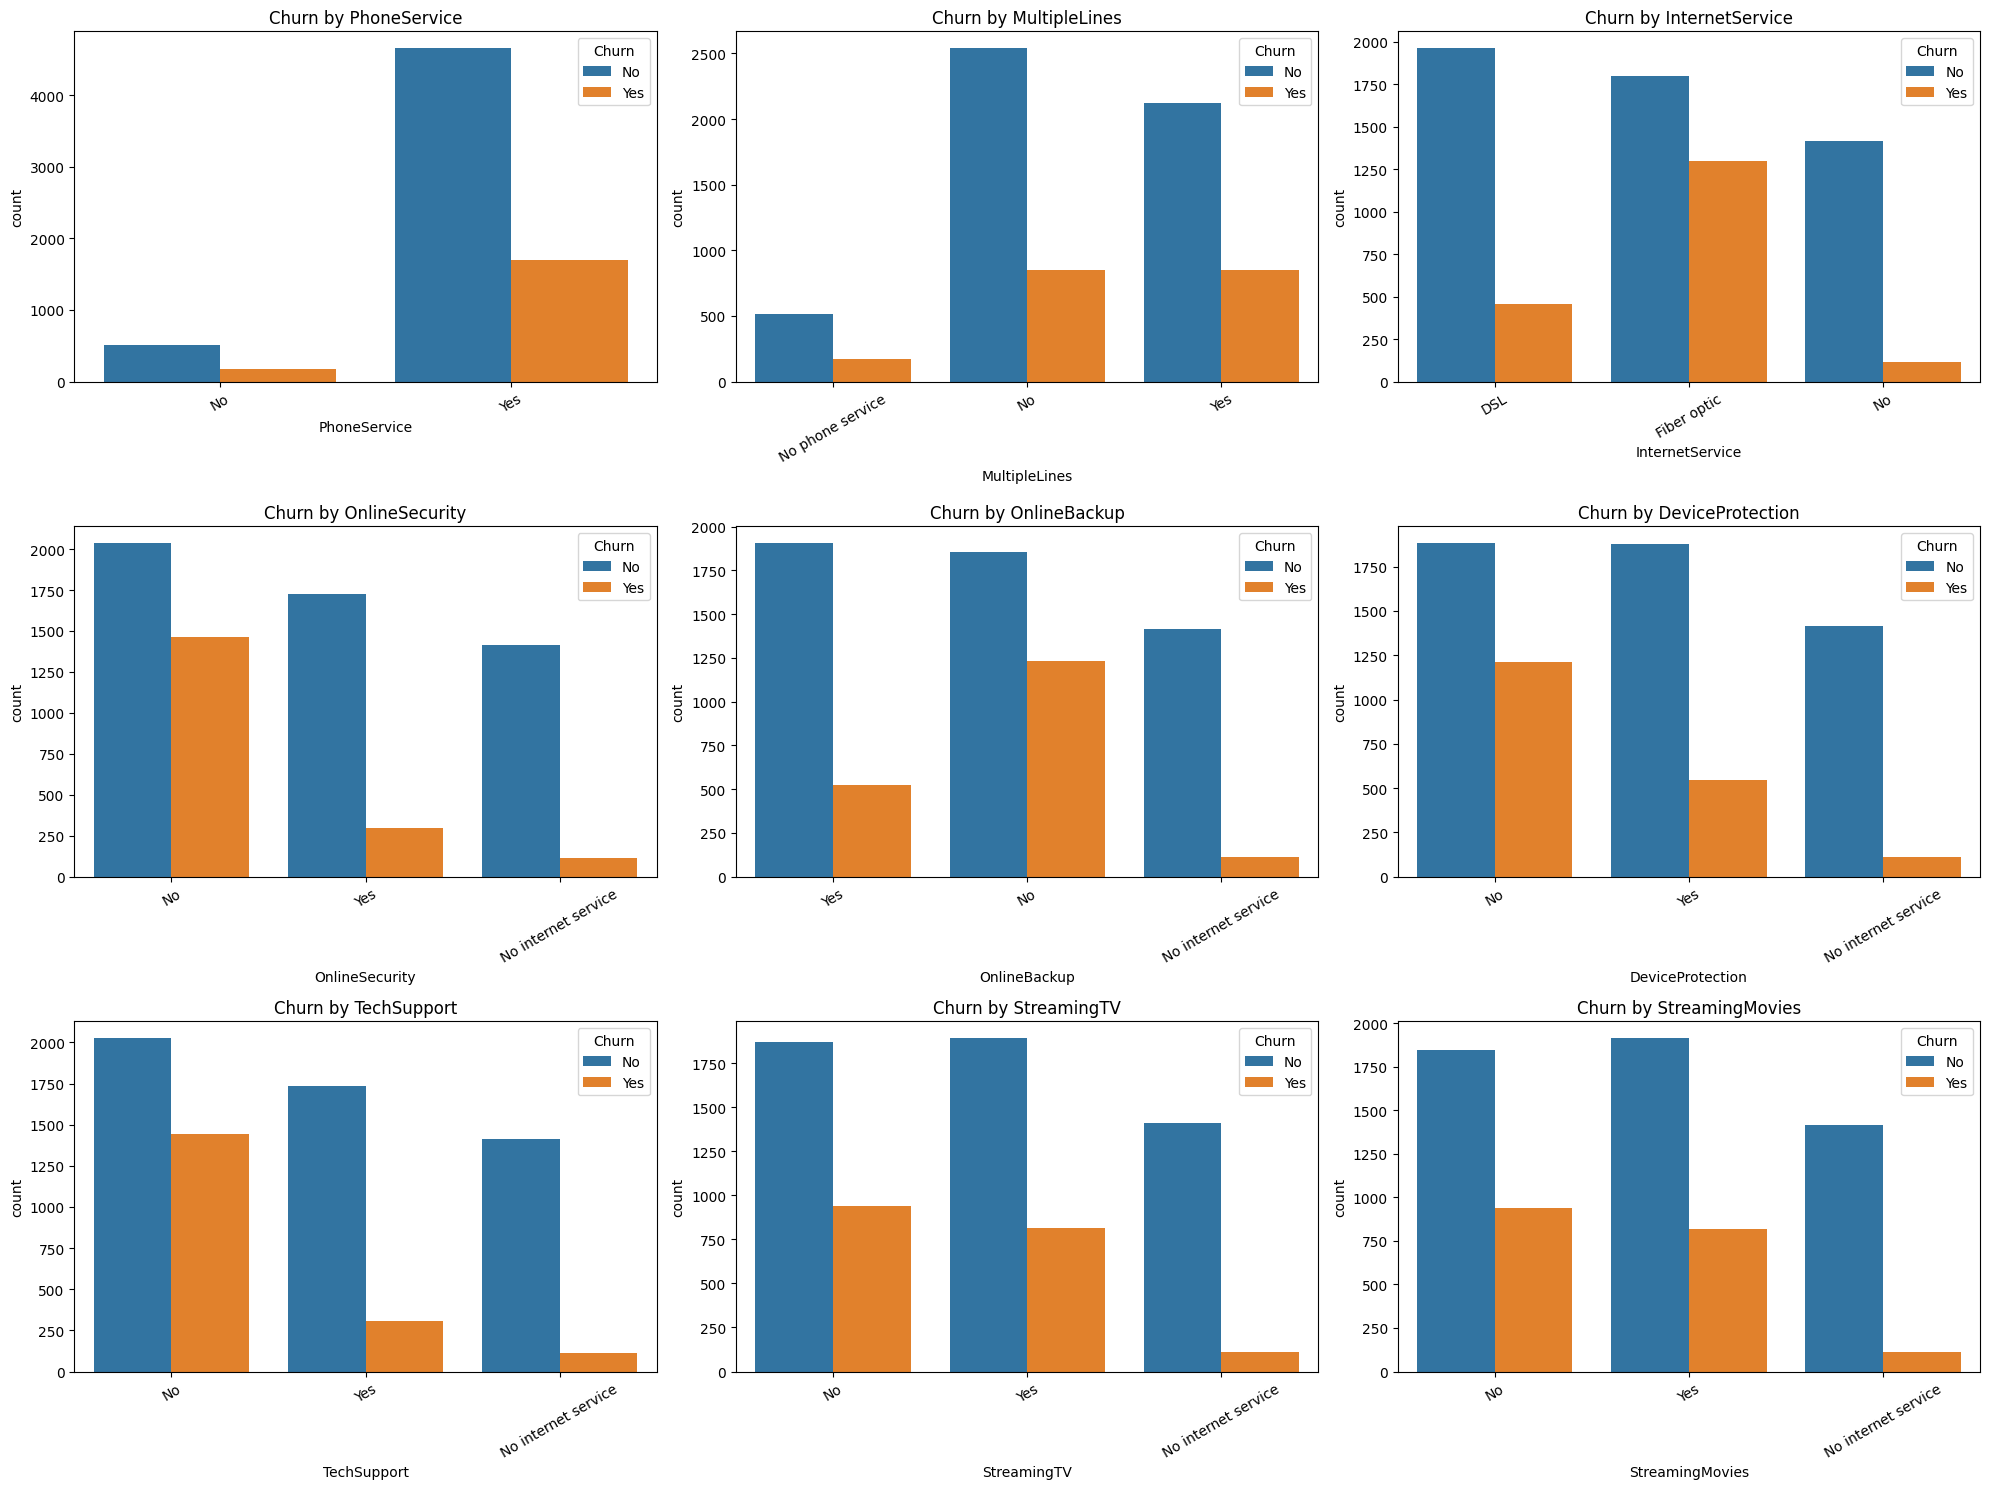

In [32]:
cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        ax=axes[i]
    )

    axes[i].set_title(f'Churn by {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Observation

Customers who do not subscribe to Online Security and Tech Support services appear to churn more frequently than customers who use these services. Additional support-related services may contribute positively to customer retention.

### Customer Tenure Analysis

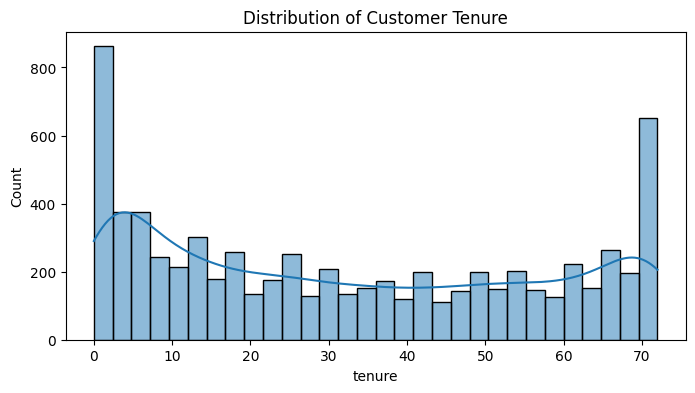

In [33]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x='tenure',
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.show()

### Monthly Charges Distribution

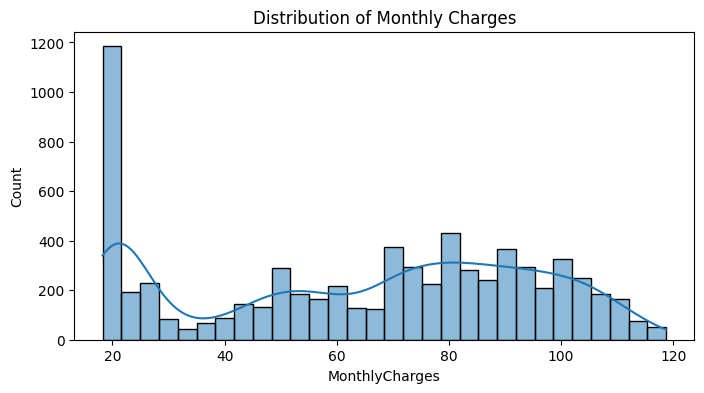

In [34]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.show()

### Observation

Monthly charges vary across customers, with most customers falling within the moderate price range. Pricing may influence customer retention decisions.

### Customer Tenure Analysis

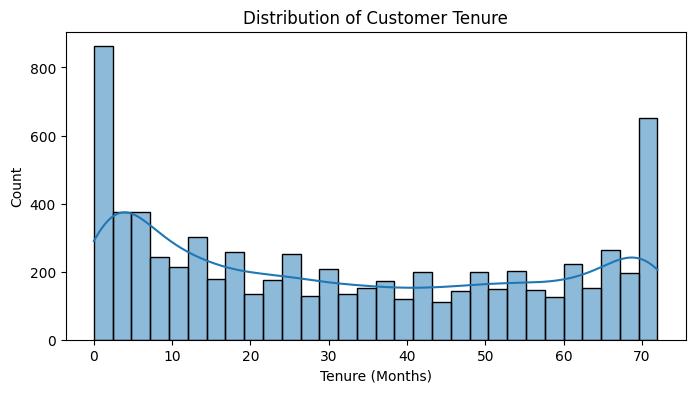

In [35]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x='tenure',
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")

plt.show()

### Observation

The tenure distribution contains both new and long-term customers. Customers with shorter tenure are generally more likely to churn compared to long-term customers.

### Monthly Charges Distribution

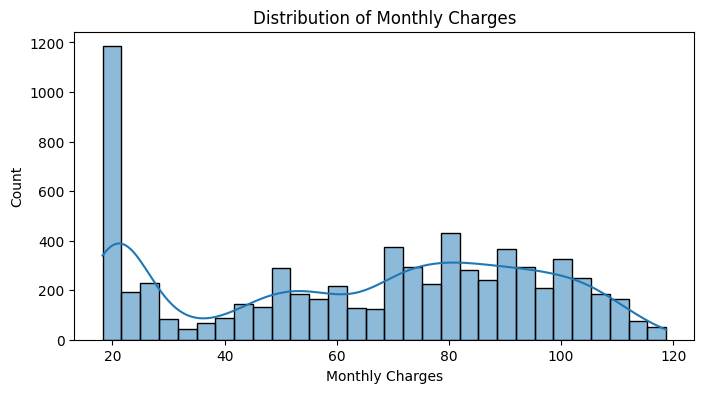

In [36]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")

plt.show()

### Observation

Monthly charges vary across customers, with most customers falling within the moderate charge range. Pricing may influence customer retention decisions.

## Feature Engineering and Encoding

In [38]:
df_ml = df.copy()

In [39]:
df_ml.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [40]:
df_ml.drop('customerID', axis=1, inplace=True)

In [47]:
df_ml.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [51]:
from sklearn.preprocessing import LabelEncoder

for col in df_ml.columns:

    if df_ml[col].dtype == 'object' or str(df_ml[col].dtype) == 'str':

        df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

In [52]:
df_ml.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


In [53]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  
 17  Monthl

## Correlation Analysis

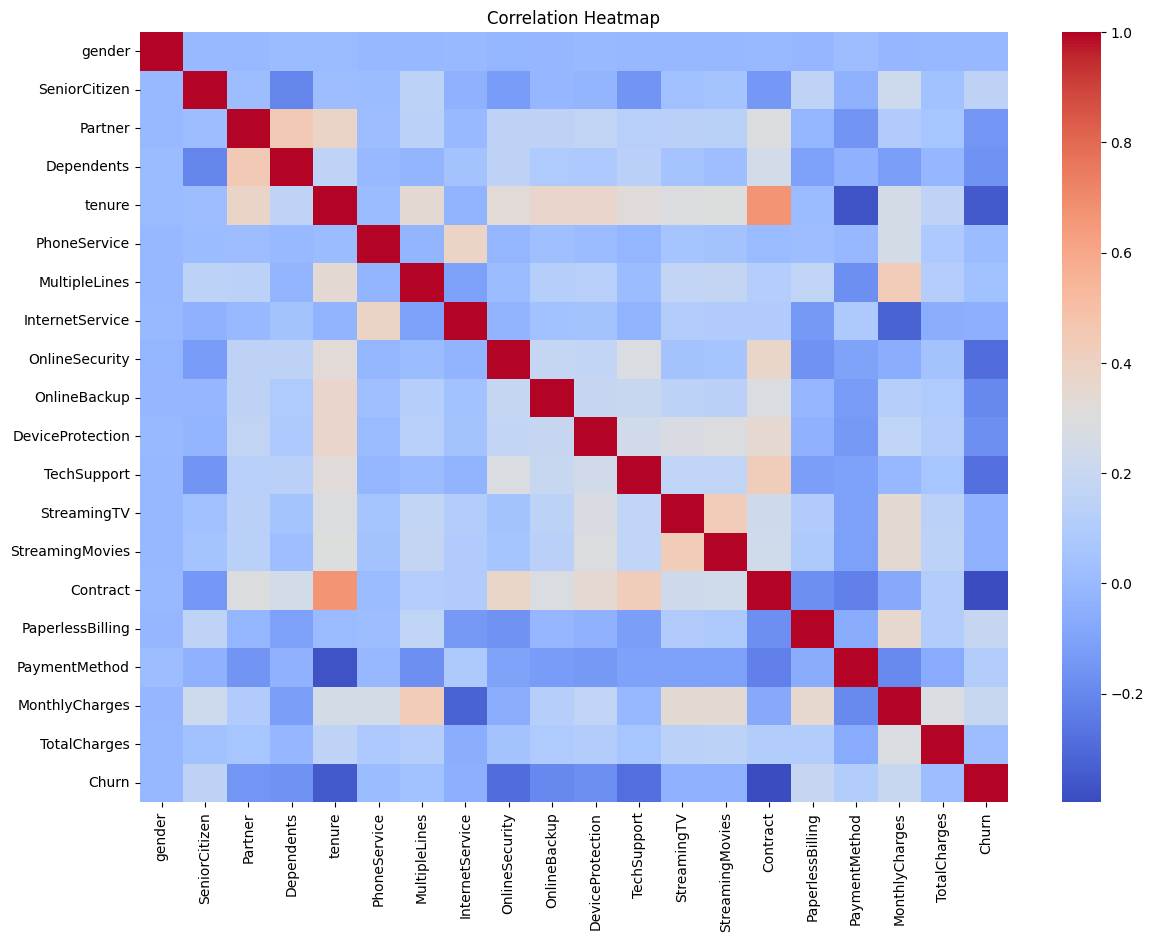

In [54]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_ml.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap helps identify relationships between variables. Features such as tenure, contract type, and monthly charges show noticeable relationships with customer churn and may influence prediction performance.

## Model Building

### Preparing Data for Machine Learning

In [55]:
X = df_ml.drop("Churn", axis=1)

y = df_ml["Churn"]

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [59]:
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8161816891412349


### Observation

The Logistic Regression model achieved an accuracy of approximately 81.6%, indicating that the selected features provide useful information for predicting customer churn.

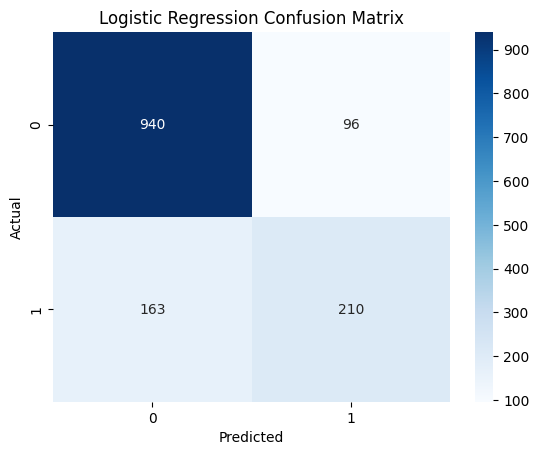

In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [63]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [64]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7984386089425124


### Observation

The Random Forest model achieved an accuracy of approximately 79.8%. Although it performed well, Logistic Regression provided slightly better predictive accuracy on this dataset.

## Model Evaluation

### Confusion Matrix

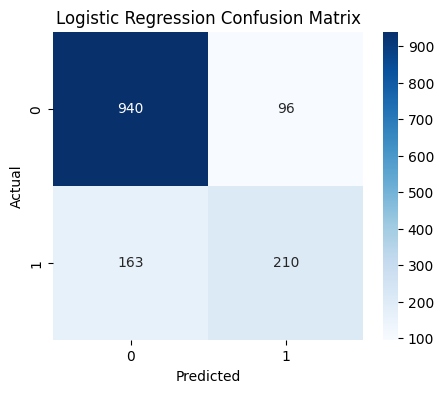

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The confusion matrix shows the number of correctly and incorrectly classified customer churn predictions. Most customers were classified correctly, indicating good model performance.

### Classification Report

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



### Observation

The classification report provides precision, recall, F1-score, and support for each class. These metrics help evaluate the model beyond overall accuracy and provide a deeper understanding of prediction performance.

## Model Comparison

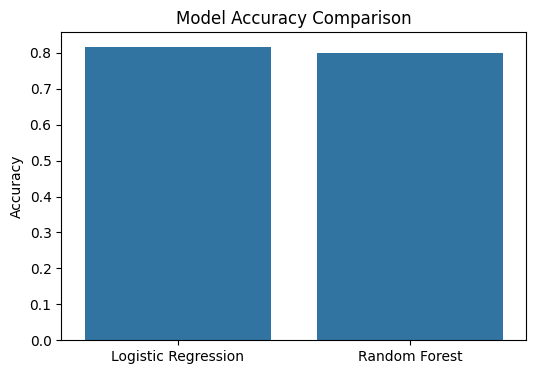

In [65]:
models = [
    "Logistic Regression",
    "Random Forest"
]

scores = [
    lr_accuracy,
    rf_accuracy
]

plt.figure(figsize=(6,4))

sns.barplot(
    x=models,
    y=scores
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

### Observation

Among the two models, Logistic Regression achieved the highest accuracy and was selected as the better-performing model for customer churn prediction.

## Business Insights

- Customers with month-to-month contracts are more likely to churn.
- Customers with shorter tenure tend to leave the service more frequently.
- Customers without Online Security and Tech Support services show higher churn rates.
- Longer contract durations contribute positively to customer retention.
- Machine learning models can help identify customers at risk of churn and support retention strategies.

## Conclusion

In this project, customer churn data was analyzed using machine learning techniques. Data cleaning, exploratory data analysis, feature engineering, and predictive modeling were successfully performed.

Customer behavior was examined using various visualizations, revealing important factors such as contract type, tenure, and service subscriptions that influence churn.

Two machine learning models, Logistic Regression and Random Forest, were trained and evaluated. Logistic Regression achieved the highest accuracy of approximately 81.6%, making it the preferred model for predicting customer churn in this dataset.

The insights obtained from this analysis can help businesses identify customers at risk of leaving and support data-driven customer retention strategies.